In [6]:
import os
import pandas as pd
current_dir = os.getcwd()
# This navigates up one level to the root, then into data/processed/
project_root = os.path.dirname(current_dir)
daily_path = os.path.join(project_root, 'data', 'processed', 'Cleaned_Daily_Final.csv')
monthly_path = os.path.join(project_root, 'data', 'processed', 'Cleaned_Monthly_Final.csv')

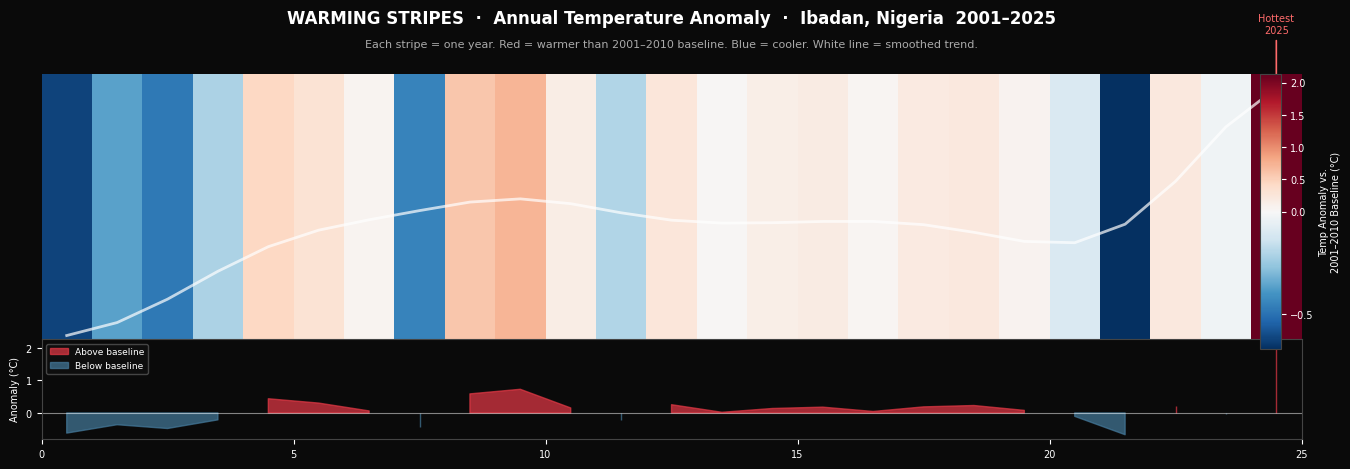

Fig 1 done


In [11]:
# ══════════════════════════════════════════════════════════════════════════
# FIGURE 1: WARMING STRIPES  (publication-quality, improved)
# ══════════════════════════════════════════════════════════════════════════
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from scipy.ndimage import gaussian_filter1d
import warnings; warnings.filterwarnings('ignore')

daily   = pd.read_csv(daily_path)
monthly = pd.read_csv(monthly_path)

month_order = ['Jan','Feb','Mar','April','May','June','July','Aug','Sep','Oct','Nov','Dec']
m_map = {'Apr':'April','Jun':'June','Jul':'July'}
monthly['Month'] = monthly['Month'].replace(m_map)
monthly['Month_Num'] = monthly['Month'].map({m:i+1 for i,m in enumerate(month_order)})
monthly['Date'] = pd.to_datetime(
    monthly['Year'].astype(int).astype(str) + '-' +
    monthly['Month_Num'].astype(int).astype(str).str.zfill(2) + '-01')
monthly = monthly.sort_values('Date').reset_index(drop=True)

DARK = '#1D3557'

# ── yearly means
yearly_temp = monthly.groupby('Year')['AVERAGE TEMPERATURE (Deg C)'].mean().dropna()
years = yearly_temp.index.astype(int)
temps = yearly_temp.values

# baseline = first 10 years mean
baseline = temps[:10].mean()
anomalies = temps - baseline

norm = mcolors.TwoSlopeNorm(vmin=anomalies.min(), vcenter=0, vmax=anomalies.max())
cmap = plt.get_cmap('RdBu_r')

fig = plt.figure(figsize=(14, 5), facecolor='#0A0A0A')
ax_stripes = fig.add_axes([0.05, 0.28, 0.90, 0.55])  # main stripes
ax_line    = fig.add_axes([0.05, 0.10, 0.90, 0.20], sharex=None)  # trend line below

for i, (yr, a) in enumerate(zip(years, anomalies)):
    ax_stripes.add_patch(Rectangle((i, 0), 1, 1, color=cmap(norm(a)), linewidth=0))

# overlay smoothed trend line
smooth = gaussian_filter1d(temps, sigma=2)
x_pos  = np.arange(len(temps)) + 0.5
ax_stripes.plot(x_pos, np.interp(smooth, [smooth.min(), smooth.max()], [0.05, 0.95]),
                color='white', lw=2.0, alpha=0.7, zorder=5)

ax_stripes.set(xlim=(0, len(temps)), ylim=(0,1), yticks=[])
ax_stripes.set_xticks(np.arange(len(temps)) + 0.5)
ax_stripes.set_xticklabels(years, rotation=45, fontsize=8, color='white')
ax_stripes.tick_params(colors='white')
for spine in ax_stripes.spines.values(): spine.set_visible(False)

# annotate hottest/coldest
hot_i = np.argmax(anomalies)
cold_i = np.argmin(anomalies)
ax_stripes.annotate(f'Hottest\n{years[hot_i]}', xy=(hot_i+0.5, 0.95),
    xytext=(hot_i+0.5, 1.15), textcoords='data',
    fontsize=7, color='#FF6B6B', ha='center',
    arrowprops=dict(arrowstyle='->', color='#FF6B6B', lw=1.2))
ax_stripes.annotate(f'Coolest\n{years[cold_i]}', xy=(cold_i+0.5, 0.05),
    xytext=(cold_i+0.5, -0.22), textcoords='data',
    fontsize=7, color='#74B3CE', ha='center',
    arrowprops=dict(arrowstyle='->', color='#74B3CE', lw=1.2))

# bottom bar: anomaly line
ax_line.fill_between(x_pos, anomalies, 0,
    where=anomalies>=0, color='#E63946', alpha=0.7, label='Above baseline')
ax_line.fill_between(x_pos, anomalies, 0,
    where=anomalies<0,  color='#457B9D', alpha=0.7, label='Below baseline')
ax_line.axhline(0, color='white', lw=0.8, alpha=0.5)
ax_line.set_xlim(0, len(temps))
ax_line.set_facecolor('#0A0A0A')
ax_line.tick_params(colors='white', labelsize=7)
ax_line.set_ylabel('Anomaly (°C)', color='white', fontsize=7)
ax_line.legend(loc='upper left', fontsize=6.5, framealpha=0.3,
               labelcolor='white', facecolor='#1a1a1a')
for spine in ax_line.spines.values(): spine.set_color('#444')

# colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.28, 0.015, 0.55])
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label('Temp Anomaly vs.\n2001–2010 Baseline (°C)', color='white', fontsize=7)
cb.ax.yaxis.set_tick_params(color='white', labelcolor='white', labelsize=7)
cb.outline.set_edgecolor('#444')

fig.text(0.50, 0.96, 'WARMING STRIPES  ·  Annual Temperature Anomaly  ·  Ibadan, Nigeria  2001–2025',
         ha='center', va='top', color='white', fontsize=12, fontweight='bold')
fig.text(0.50, 0.90, 'Each stripe = one year. Red = warmer than 2001–2010 baseline. Blue = cooler. White line = smoothed trend.',
         ha='center', va='top', color='#AAAAAA', fontsize=8)
os.makedirs('assets', exist_ok=True)
plt.savefig('./assets/fig1_warming_stripes.png', dpi=200, bbox_inches='tight',
            facecolor='#0A0A0A')
plt.show()
plt.close()
print("Fig 1 done")

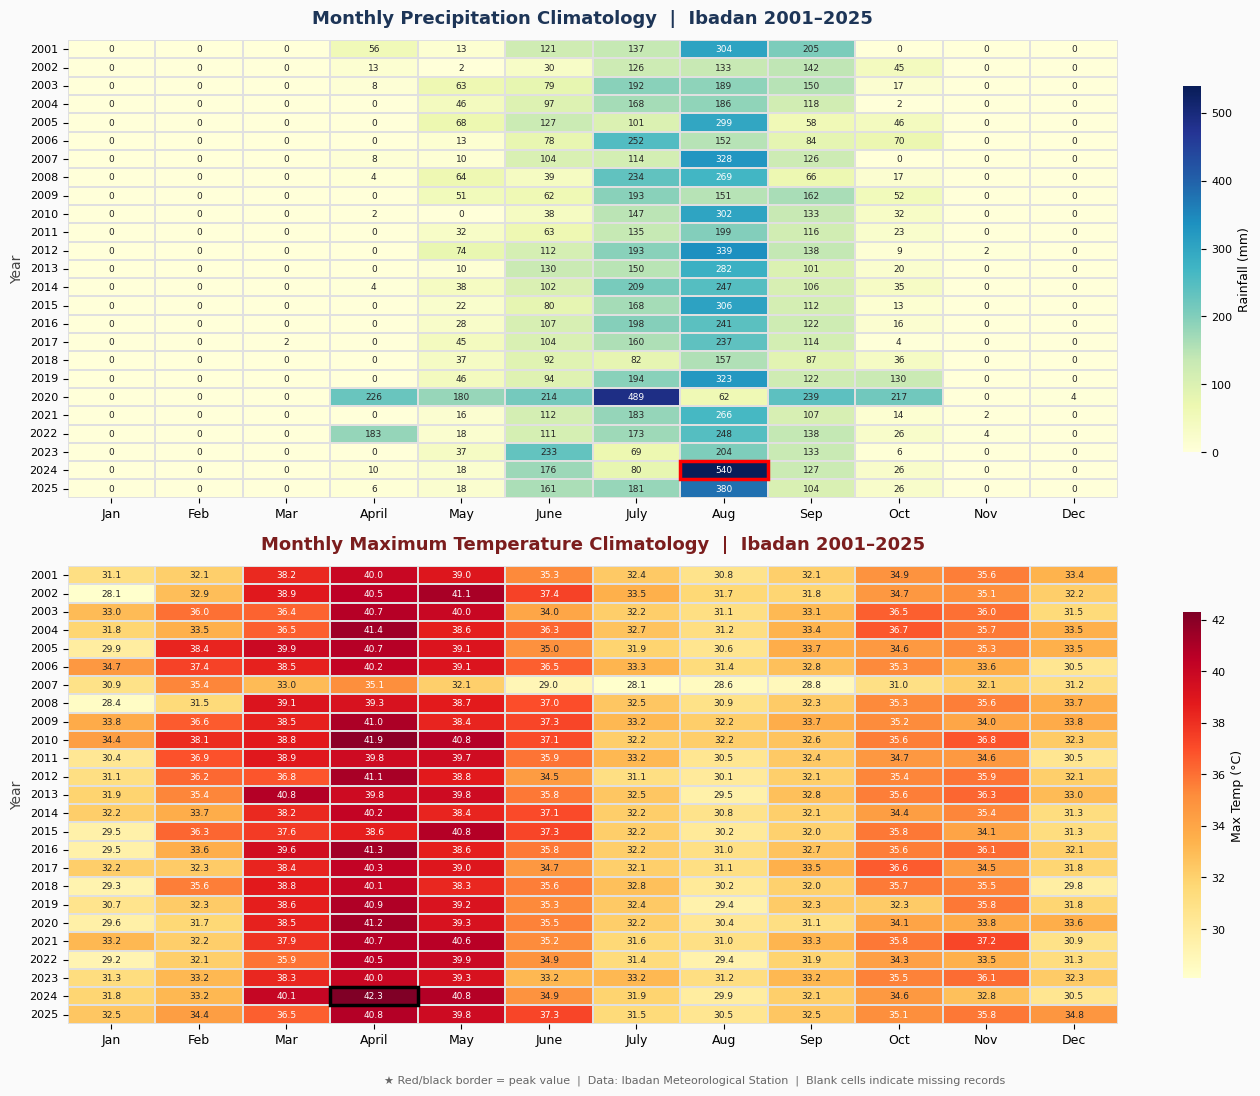

Fig 2 done


In [12]:
# ══════════════════════════════════════════════════════════════════════════
# FIGURE 2: DUAL HEATMAPS  (Precipitation + Max Temp)
# ══════════════════════════════════════════════════════════════════════════
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

monthly = pd.read_csv(monthly_path)
month_order = ['Jan','Feb','Mar','April','May','June','July','Aug','Sep','Oct','Nov','Dec']
m_map = {'Apr':'April','Jun':'June','Jul':'July'}
monthly['Month'] = monthly['Month'].replace(m_map)

fig, axes = plt.subplots(2, 1, figsize=(14, 11), facecolor='#FAFAFA')
fig.patch.set_facecolor('#FAFAFA')

# ── Rainfall heatmap ──
rain_pivot = monthly.pivot_table(index='Year', columns='Month',
                                  values='RAINFALL (mm)', aggfunc='mean').reindex(columns=month_order)
rain_pivot.index = rain_pivot.index.astype(int)

mask_r = rain_pivot.isnull()
g1 = sns.heatmap(rain_pivot, cmap='YlGnBu', ax=axes[0],
                  cbar_kws={'label': 'Rainfall (mm)', 'shrink': 0.8},
                  linewidths=0.3, linecolor='#E0E0E0',
                  annot=True, fmt='.0f', annot_kws={'size': 6.5},
                  mask=mask_r)
axes[0].set_title('Monthly Precipitation Climatology  |  Ibadan 2001–2025',
                   fontsize=13, fontweight='bold', pad=12, color='#1D3557')
axes[0].set_xlabel('')
axes[0].set_ylabel('Year', fontsize=10, color='#444')
axes[0].tick_params(axis='x', rotation=0, labelsize=9)
axes[0].tick_params(axis='y', labelsize=8)
axes[0].collections[0].colorbar.ax.tick_params(labelsize=8)
axes[0].collections[0].colorbar.set_label('Rainfall (mm)', fontsize=9)

# highlight wettest cell
r_vals = rain_pivot.values
if not np.all(np.isnan(r_vals)):
    rmax = np.nanargmax(r_vals)
    ri, ci = np.unravel_index(rmax, r_vals.shape)
    axes[0].add_patch(plt.Rectangle((ci, ri), 1, 1, fill=False,
                                     edgecolor='red', lw=2.5, zorder=5))

# ── Max Temp heatmap ──
temp_pivot = monthly.pivot_table(index='Year', columns='Month',
                                  values='MAXIMUM TEMPERATURE (Deg C)', aggfunc='mean').reindex(columns=month_order)
temp_pivot.index = temp_pivot.index.astype(int)

mask_t = temp_pivot.isnull()
g2 = sns.heatmap(temp_pivot, cmap='YlOrRd', ax=axes[1],
                  cbar_kws={'label': 'Max Temp (°C)', 'shrink': 0.8},
                  linewidths=0.3, linecolor='#E0E0E0',
                  annot=True, fmt='.1f', annot_kws={'size': 6.5},
                  mask=mask_t)
axes[1].set_title('Monthly Maximum Temperature Climatology  |  Ibadan 2001–2025',
                   fontsize=13, fontweight='bold', pad=12, color='#7B1D1D')
axes[1].set_xlabel('')
axes[1].set_ylabel('Year', fontsize=10, color='#444')
axes[1].tick_params(axis='x', rotation=0, labelsize=9)
axes[1].tick_params(axis='y', labelsize=8)
axes[1].collections[0].colorbar.ax.tick_params(labelsize=8)
axes[1].collections[0].colorbar.set_label('Max Temp (°C)', fontsize=9)

# highlight hottest cell
t_vals = temp_pivot.values
if not np.all(np.isnan(t_vals)):
    tmax = np.nanargmax(t_vals)
    ti, tci = np.unravel_index(tmax, t_vals.shape)
    axes[1].add_patch(plt.Rectangle((tci, ti), 1, 1, fill=False,
                                     edgecolor='black', lw=2.5, zorder=5))

# Season bands annotation on top heatmap
season_spans = [('DJF', [0,1,11], '#BDE0FE'), ('MAM', [2,3,4], '#B7E4C7'),
                ('JJA', [5,6,7], '#FFC8A2'), ('SON', [8,9,10], '#C8B6FF')]
# (skip—would need custom x positions; labels above suffice)

fig.text(0.5, 0.01,
         '★ Red/black border = peak value  |  Data: Ibadan Meteorological Station  |  Blank cells indicate missing records',
         ha='center', fontsize=8, color='#666')

plt.tight_layout(rect=[0, 0.03, 1, 1])
os.makedirs('assets', exist_ok=True)
plt.savefig('assets/fig2_heatmaps.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
plt.close()
print("Fig 2 done")

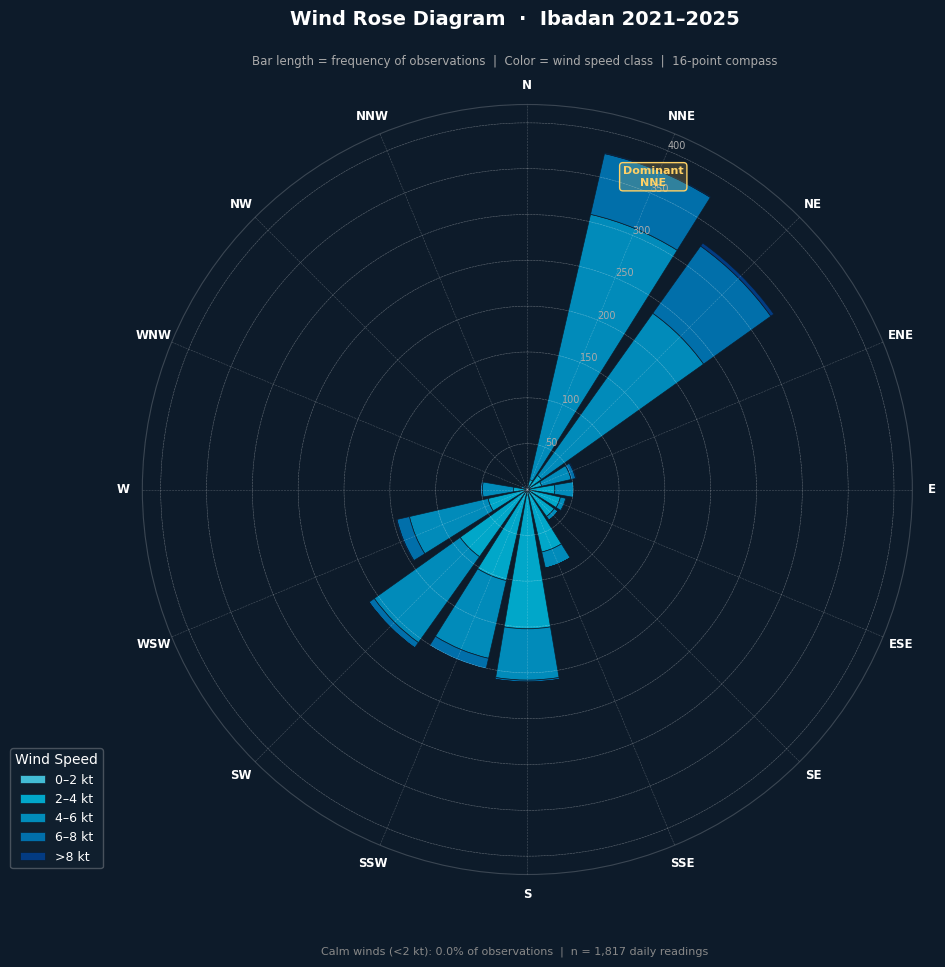

In [13]:
# ══════════════════════════════════════════════════════════════════════════
# FIGURE 3: WIND ROSE
# ══════════════════════════════════════════════════════════════════════════
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

daily   = pd.read_csv(daily_path)

ws = daily['WIND SPEED (kt)'].dropna()
wd = daily['WIND DIRECTION (Degrees)'].dropna()
valid_idx = ws.index.intersection(wd.index)
ws, wd = ws.loc[valid_idx], wd.loc[valid_idx]

dir_labels = ['N','NNE','NE','ENE','E','ESE','SE','SSE',
              'S','SSW','SW','WSW','W','WNW','NW','NNW']
n_dirs = 16
bins_dir = np.linspace(0, 360, n_dirs+1)
wd_adj = (wd + 360/n_dirs/2) % 360
binned_dir = pd.cut(wd_adj, bins=bins_dir, labels=dir_labels, right=False)

speed_bins   = [0, 2, 4, 6, 8, np.inf]
speed_labels = ['0–2 kt','2–4 kt','4–6 kt','6–8 kt','>8 kt']
binned_speed = pd.cut(ws, bins=speed_bins, labels=speed_labels)

wind_df = pd.DataFrame({'dir': binned_dir, 'speed': binned_speed}).dropna()
wind_counts = wind_df.groupby(['dir','speed'], observed=True).size().unstack(fill_value=0)
# ensure all speed cols present
for sp in speed_labels:
    if sp not in wind_counts.columns:
        wind_counts[sp] = 0
wind_counts = wind_counts[speed_labels]

angles = np.linspace(0, 2*np.pi, n_dirs, endpoint=False)
bar_width = 2*np.pi / n_dirs * 0.85

fig = plt.figure(figsize=(10, 10), facecolor='#0D1B2A')
ax = fig.add_subplot(111, projection='polar', facecolor='#0D1B2A')
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi/2)

colors = ['#48CAE4','#00B4D8','#0096C7','#0077B6','#023E8A']
bottom = np.zeros(n_dirs)
for sp, col in zip(speed_labels, colors):
    vals = wind_counts.reindex(dir_labels, fill_value=0)[sp].values
    ax.bar(angles, vals, width=bar_width, bottom=bottom,
           color=col, label=sp, edgecolor='#0D1B2A', linewidth=0.5, alpha=0.92)
    bottom += vals

ax.set_xticks(angles)
ax.set_xticklabels(dir_labels, fontsize=8.5, color='white', fontweight='bold')
ax.tick_params(colors='white')
ax.yaxis.set_tick_params(labelcolor='#AAA', labelsize=7)
ax.grid(color='#FFFFFF', linestyle='--', linewidth=0.4, alpha=0.25)
ax.spines['polar'].set_color('#FFFFFF30')

# radial labels
r_ticks = ax.get_yticks()
ax.set_yticklabels([f'{int(t)}' for t in r_ticks], color='#AAAAAA', fontsize=7)
ax.set_rlabel_position(22.5)

# concentric grid circles custom
for r in r_ticks:
    ax.plot(np.linspace(0, 2*np.pi, 200), [r]*200,
            color='white', lw=0.3, alpha=0.15)

legend = ax.legend(title='Wind Speed', loc='lower left',
                   bbox_to_anchor=(-0.18, 0.0),
                   fontsize=9, title_fontsize=10,
                   framealpha=0.3, facecolor='#1a2a3a',
                   labelcolor='white')
legend.get_title().set_color('white')

# dominant direction annotation
dominant_dir = wind_counts.sum(axis=1).idxmax()
dom_angle = angles[dir_labels.index(dominant_dir)]
max_r = bottom.max() * 1.12
ax.annotate(f'Dominant\n{dominant_dir}',
    xy=(dom_angle, max_r*0.85), fontsize=8, color='#FFD166',
    ha='center', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFD16630', edgecolor='#FFD166', lw=1))

fig.text(0.5, 0.96, 'Wind Rose Diagram  ·  Ibadan 2021–2025',
         ha='center', color='white', fontsize=14, fontweight='bold')
fig.text(0.5, 0.92,
         'Bar length = frequency of observations  |  Color = wind speed class  |  16-point compass',
         ha='center', color='#AAAAAA', fontsize=8.5)

pct_calm = (ws < 2).sum() / len(ws) * 100
fig.text(0.5, 0.03,
         f'Calm winds (<2 kt): {pct_calm:.1f}% of observations  |  n = {len(ws):,} daily readings',
         ha='center', color='#888', fontsize=8)

plt.savefig('assets/fig3_wind_rose.png', dpi=200, bbox_inches='tight', facecolor='#0D1B2A')
plt.show()
plt.close()

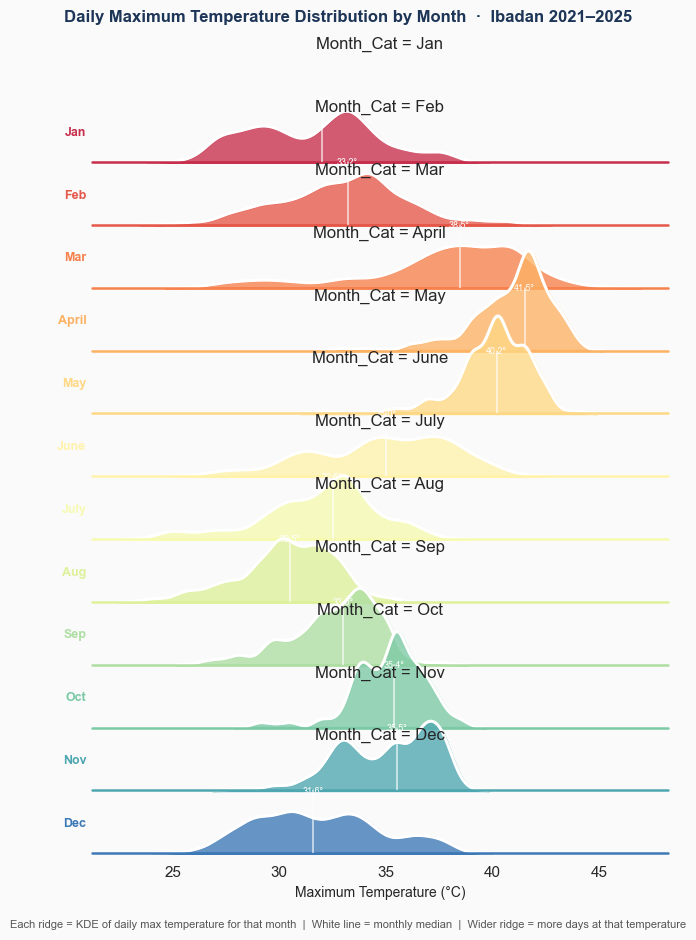

Fig 4 done


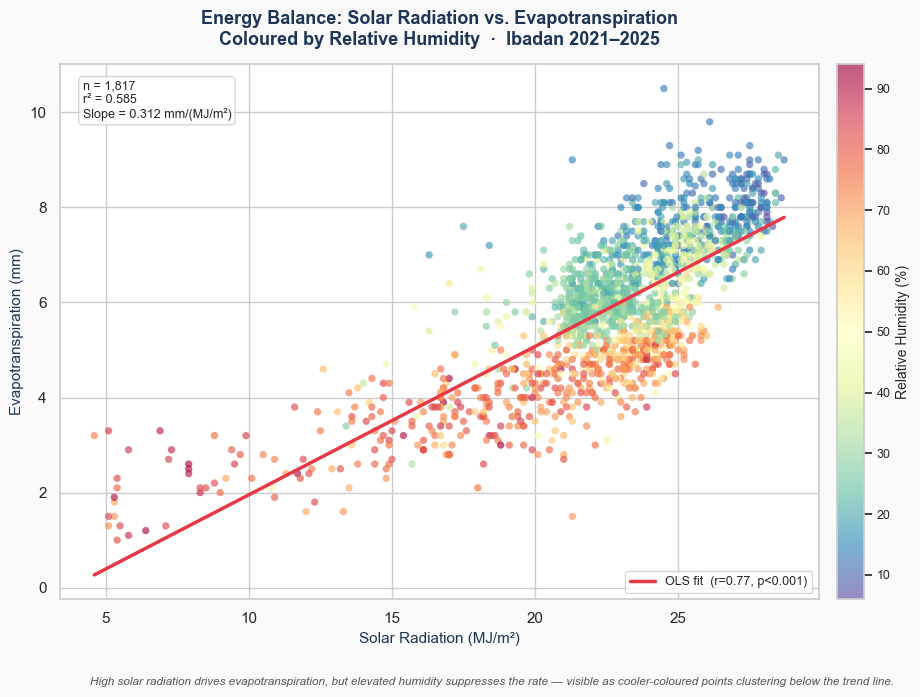

In [14]:
# ══════════════════════════════════════════════════════════════════════════
# FIGURE 4: RIDGELINE + FIGURE 5: SCATTER
# ══════════════════════════════════════════════════════════════════════════
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

daily   = pd.read_csv(daily_path)
month_order = ['Jan','Feb','Mar','April','May','June','July','Aug','Sep','Oct','Nov','Dec']
m_map = {'Apr':'April','Jun':'June','Jul':'July'}
daily['Month'] = daily['Month'].replace(m_map)
daily['Month_Cat'] = pd.Categorical(daily['Month'], categories=month_order, ordered=True)

# ──────────────────────────────────
# FIG 4: RIDGELINE
# ──────────────────────────────────
pal = sns.color_palette("Spectral", 12)
sns.set_theme(style="white", rc={"axes.facecolor": (0,0,0,0), "figure.facecolor": "#FAFAFA"})

data_r = daily.dropna(subset=['MAXIMUM TEMPERATURE (Deg C)'])
g = sns.FacetGrid(data_r, row="Month_Cat", hue="Month_Cat",
                  palette=pal, aspect=9, height=0.75,
                  row_order=month_order)

g.map(sns.kdeplot, "MAXIMUM TEMPERATURE (Deg C)",
      bw_adjust=0.6, clip_on=False, fill=True, alpha=0.78, linewidth=1.8)
g.map(sns.kdeplot, "MAXIMUM TEMPERATURE (Deg C)",
      clip_on=False, color="white", lw=2.2, bw_adjust=0.6)
g.refline(y=0, linewidth=1.8, linestyle="-", color=None, clip_on=False)

# month labels + median markers
for i, (ax, month) in enumerate(zip(g.axes.flat, month_order)):
    sub = data_r[data_r['Month_Cat'] == month]['MAXIMUM TEMPERATURE (Deg C)']
    med = sub.median()
    ax.text(-0.01, 0.28, month, fontweight='bold', color=pal[i],
            ha='right', va='center', transform=ax.transAxes, fontsize=9)
    ax.axvline(med, ymin=0, ymax=0.6, color='white', lw=1.2, alpha=0.7, zorder=10)
    ax.text(med, ax.get_ylim()[1]*0.55, f'{med:.1f}°', fontsize=6.5,
            color='white', ha='center', va='bottom', zorder=11)

g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
g.figure.subplots_adjust(hspace=-0.40)
g.set_xlabels('Maximum Temperature (°C)', fontsize=10)

g.figure.suptitle('Daily Maximum Temperature Distribution by Month  ·  Ibadan 2021–2025',
                   fontweight='bold', fontsize=12, y=1.01, color='#1D3557')
g.figure.text(0.5, -0.01,
    'Each ridge = KDE of daily max temperature for that month  |  White line = monthly median  |  Wider ridge = more days at that temperature',
    ha='center', fontsize=8, color='#555')

g.figure.savefig('assets/fig4_ridgeline.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
plt.close('all')
print("Fig 4 done")

# ──────────────────────────────────
# FIG 5: ENERGY BALANCE SCATTER
# ──────────────────────────────────
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 7), facecolor='#FAFAFA')
fig.patch.set_facecolor('#FAFAFA')

sc_data = daily.dropna(subset=['SOLAR RADIATION (MJ/m2)','EVAPOTRANSPIRATION (mm)','RELATIVE HUMIDITY (%)'])

scatter = ax.scatter(sc_data['SOLAR RADIATION (MJ/m2)'],
                     sc_data['EVAPOTRANSPIRATION (mm)'],
                     c=sc_data['RELATIVE HUMIDITY (%)'],
                     cmap='Spectral_r', alpha=0.65, s=28,
                     edgecolors='none', zorder=3)

# regression line
from scipy import stats
slope, intercept, r, p, se = stats.linregress(
    sc_data['SOLAR RADIATION (MJ/m2)'], sc_data['EVAPOTRANSPIRATION (mm)'])
x_fit = np.linspace(sc_data['SOLAR RADIATION (MJ/m2)'].min(),
                    sc_data['SOLAR RADIATION (MJ/m2)'].max(), 200)
ax.plot(x_fit, slope*x_fit+intercept, color='#E63946', lw=2.5, zorder=5,
        label=f'OLS fit  (r={r:.2f}, p{"<0.001" if p<0.001 else f"={p:.3f}"})')

cb = fig.colorbar(scatter, ax=ax, pad=0.02)
cb.set_label('Relative Humidity (%)', fontsize=10)
cb.ax.tick_params(labelsize=9)

ax.set_xlabel('Solar Radiation (MJ/m²)', fontsize=11, color='#1D3557')
ax.set_ylabel('Evapotranspiration (mm)', fontsize=11, color='#1D3557')
ax.set_title('Energy Balance: Solar Radiation vs. Evapotranspiration\nColoured by Relative Humidity  ·  Ibadan 2021–2025',
             fontsize=13, fontweight='bold', color='#1D3557', pad=14)

# add stats box
stats_txt = (f'n = {len(sc_data):,}\n'
             f'r² = {r**2:.3f}\n'
             f'Slope = {slope:.3f} mm/(MJ/m²)')
ax.text(0.03, 0.97, stats_txt, transform=ax.transAxes,
        fontsize=9, va='top', ha='left',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#CCC'))
ax.legend(fontsize=9, loc='lower right')

fig.text(0.5, 0.01,
    'High solar radiation drives evapotranspiration, but elevated humidity suppresses the rate — visible as cooler-coloured points clustering below the trend line.',
    ha='center', fontsize=8.5, color='#555', style='italic')

plt.tight_layout(rect=[0,0.04,1,1])
plt.savefig('assets/fig5_energy_scatter.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
plt.close()

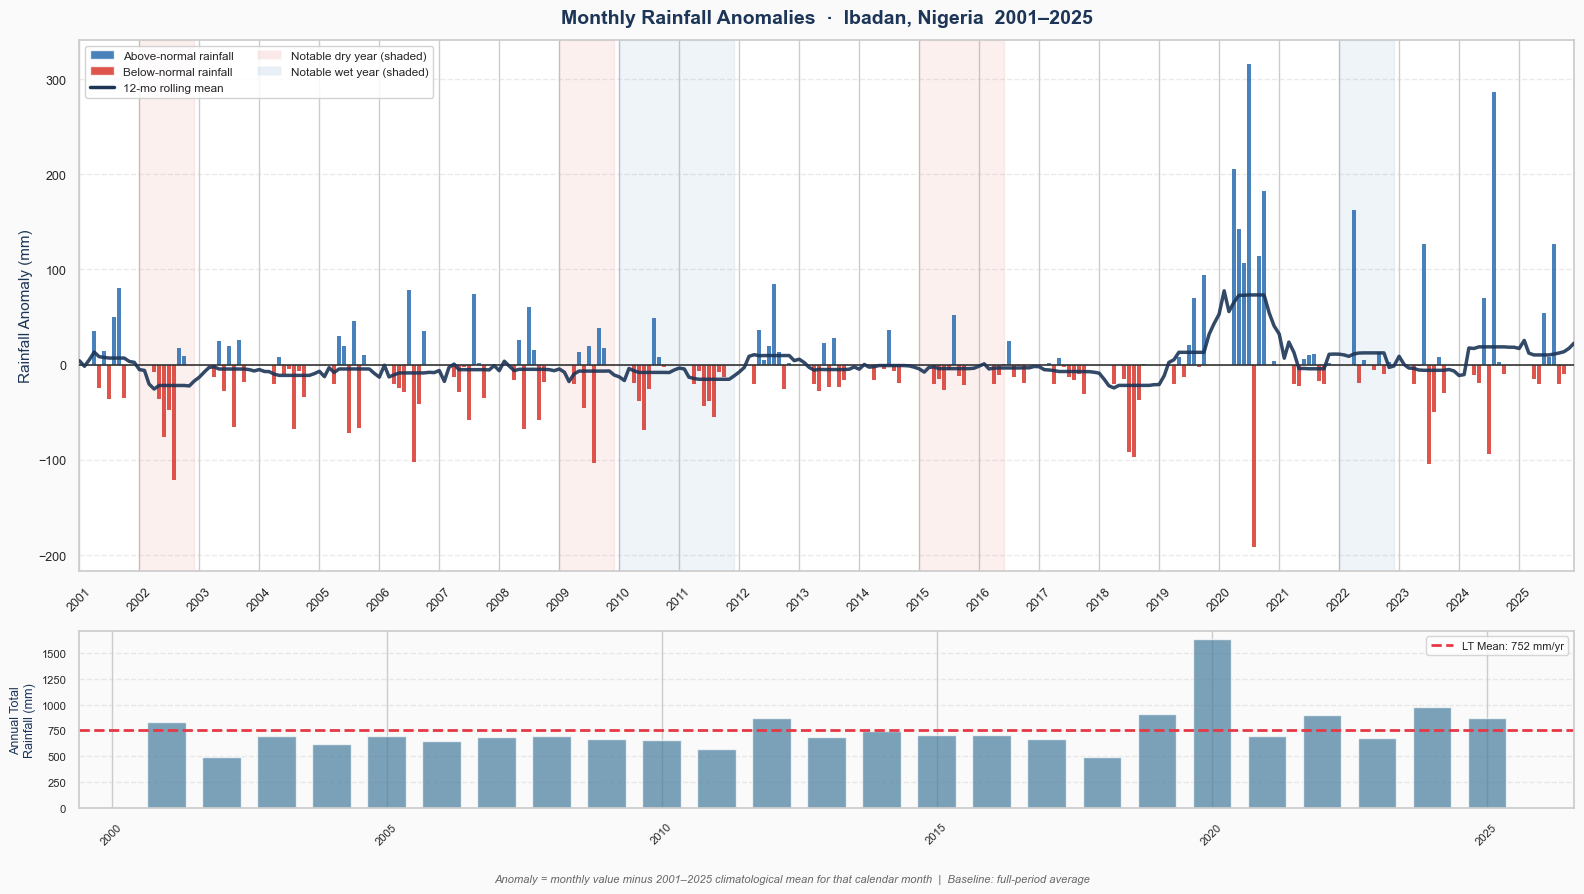

Fig 6 done


In [15]:
# ══════════════════════════════════════════════════════════════════════════
# FIGURE 6: RAINFALL ANOMALY DIVERGING BARS  (improved)
# ══════════════════════════════════════════════════════════════════════════
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.ndimage import gaussian_filter1d
import warnings; warnings.filterwarnings('ignore')

monthly = pd.read_csv(monthly_path)
month_order = ['Jan','Feb','Mar','April','May','June','July','Aug','Sep','Oct','Nov','Dec']
m_map = {'Apr':'April','Jun':'June','Jul':'July'}
monthly['Month'] = monthly['Month'].replace(m_map)
monthly['Month_Num'] = monthly['Month'].map({m:i+1 for i,m in enumerate(month_order)})
monthly['Date'] = pd.to_datetime(
    monthly['Year'].astype(int).astype(str) + '-' +
    monthly['Month_Num'].astype(int).astype(str).str.zfill(2) + '-01')
monthly = monthly.sort_values('Date').reset_index(drop=True)

# anomaly calc
month_means = monthly.groupby('Month')['RAINFALL (mm)'].mean()
monthly['Rain_Anomaly'] = monthly.apply(lambda r: r['RAINFALL (mm)'] - month_means[r['Month']], axis=1)

fig, (ax_main, ax_annual) = plt.subplots(2, 1, figsize=(16, 9),
                                          gridspec_kw={'height_ratios':[3,1]},
                                          facecolor='#FAFAFA')
fig.patch.set_facecolor('#FAFAFA')

# colours
colors_bar = ['#2166AC' if v >= 0 else '#D73027' for v in monthly['Rain_Anomaly']]
ax_main.bar(monthly['Date'], monthly['Rain_Anomaly'], color=colors_bar,
            width=25, linewidth=0, alpha=0.82, zorder=3)

# smoothed 12-month rolling mean of anomaly
roll_smooth = monthly['Rain_Anomaly'].rolling(12, center=True, min_periods=6).mean()
ax_main.plot(monthly['Date'], roll_smooth, color='#1D3557', lw=2.5, zorder=5,
             label='12-month rolling mean', alpha=0.9)

ax_main.axhline(0, color='#333', linewidth=1.2, zorder=4)
ax_main.set_xlim(monthly['Date'].min(), monthly['Date'].max())
ax_main.xaxis.set_major_locator(mdates.YearLocator())
ax_main.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_main.tick_params(axis='x', rotation=45, labelsize=9)
ax_main.tick_params(axis='y', labelsize=9)
ax_main.set_ylabel('Rainfall Anomaly (mm)', fontsize=11, color='#1D3557')
ax_main.set_title('Monthly Rainfall Anomalies  ·  Ibadan, Nigeria  2001–2025',
                  fontsize=14, fontweight='bold', color='#1D3557', pad=12)

# shade known meteorological events / ENSO years (approximate)
dry_periods = [('2002-01-01','2002-12-01'), ('2009-01-01','2009-12-01'),
               ('2015-01-01','2016-06-01')]
wet_periods  = [('2010-01-01','2011-12-01'), ('2022-01-01','2022-12-01')]
for s,e in dry_periods:
    ax_main.axvspan(pd.to_datetime(s), pd.to_datetime(e),
                    color='#D73027', alpha=0.07, zorder=1)
for s,e in wet_periods:
    ax_main.axvspan(pd.to_datetime(s), pd.to_datetime(e),
                    color='#2166AC', alpha=0.07, zorder=1)

# legend patches
from matplotlib.patches import Patch
leg_items = [
    Patch(facecolor='#2166AC', alpha=0.82, label='Above-normal rainfall'),
    Patch(facecolor='#D73027', alpha=0.82, label='Below-normal rainfall'),
    plt.Line2D([0],[0], color='#1D3557', lw=2.5, label='12-mo rolling mean'),
    Patch(facecolor='#D73027', alpha=0.10, label='Notable dry year (shaded)'),
    Patch(facecolor='#2166AC', alpha=0.10, label='Notable wet year (shaded)'),
]
ax_main.legend(handles=leg_items, fontsize=8.5, loc='upper left',
               framealpha=0.85, ncol=2)
ax_main.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

# ── bottom: annual total rainfall ──────────────────────────────────────
annual_rain = monthly.groupby('Year')['RAINFALL (mm)'].sum()
years_a = annual_rain.index.astype(int)
bars_a = ax_annual.bar(years_a, annual_rain.values, color='#457B9D', alpha=0.7, width=0.7)
# long-term mean line
lt_mean = annual_rain.mean()
ax_annual.axhline(lt_mean, color='#E63946', lw=2, linestyle='--',
                  label=f'LT Mean: {lt_mean:.0f} mm/yr')
ax_annual.set_ylabel('Annual Total\nRainfall (mm)', fontsize=9, color='#1D3557')
ax_annual.tick_params(axis='y', labelsize=8)
ax_annual.tick_params(axis='x', rotation=45, labelsize=8)
ax_annual.legend(fontsize=8, loc='upper right')
ax_annual.grid(axis='y', linestyle='--', alpha=0.4)
ax_annual.set_facecolor('#FAFAFA')

fig.text(0.5, 0.01,
    'Anomaly = monthly value minus 2001–2025 climatological mean for that calendar month  |  Baseline: full-period average',
    ha='center', fontsize=8, color='#666', style='italic')

plt.tight_layout(rect=[0,0.03,1,1])
plt.savefig('assets/fig6_rainfall_anomaly.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
plt.close()
print("Fig 6 done")

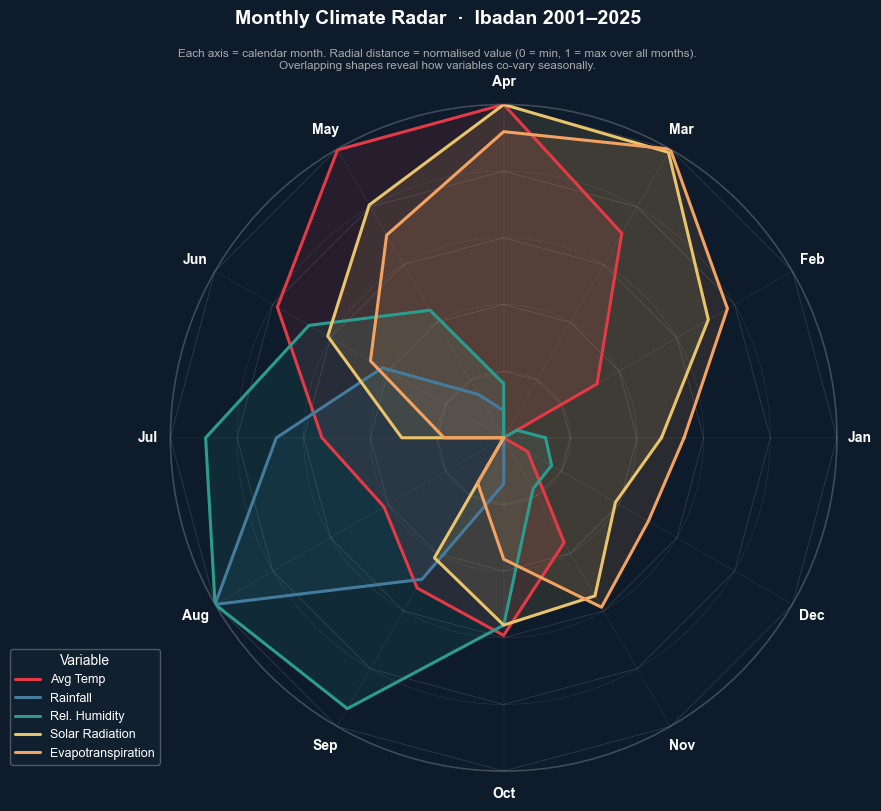

Fig 7 done


In [16]:
# ══════════════════════════════════════════════════════════════════════════
# FIGURE 7: CLIMATE SPIDER / RADAR — monthly climatological averages
# ══════════════════════════════════════════════════════════════════════════
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

monthly = pd.read_csv(monthly_path)
month_order = ['Jan','Feb','Mar','April','May','June','July','Aug','Sep','Oct','Nov','Dec']
m_map = {'Apr':'April','Jun':'June','Jul':'July'}
monthly['Month'] = monthly['Month'].replace(m_map)
monthly['Month_Num'] = monthly['Month'].map({m:i+1 for i,m in enumerate(month_order)})

clim = monthly.groupby('Month').agg({
    'AVERAGE TEMPERATURE (Deg C)': 'mean',
    'RAINFALL (mm)': 'mean',
    'RELATIVE HUMIDITY (%)': 'mean',
    'SOLAR RADIATION (MJ/m2)': 'mean',
    'WIND SPEED (kt)': 'mean',
    'EVAPOTRANSPIRATION (mm)': 'mean',
}).reindex(month_order)

# normalise each variable 0→1
clim_norm = (clim - clim.min()) / (clim.max() - clim.min())

labels_short = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
N = len(month_order)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close

vars_to_plot = {
    'AVERAGE TEMPERATURE (Deg C)': ('#E63946', 'Avg Temp'),
    'RAINFALL (mm)':               ('#457B9D', 'Rainfall'),
    'RELATIVE HUMIDITY (%)':       ('#2A9D8F', 'Rel. Humidity'),
    'SOLAR RADIATION (MJ/m2)':     ('#E9C46A', 'Solar Radiation'),
    'EVAPOTRANSPIRATION (mm)':     ('#F4A261', 'Evapotranspiration'),
}

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'polar': True}, facecolor='#0D1B2A')
ax.set_facecolor('#0D1B2A')

for col, (color, label) in vars_to_plot.items():
    vals = clim_norm[col].values.tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=color, lw=2.2, label=label, zorder=4)
    ax.fill(angles, vals, color=color, alpha=0.12, zorder=3)

# grid & labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_short, color='white', fontsize=10, fontweight='bold')
ax.set_yticklabels([], color='white')
ax.set_ylim(0, 1)
for r in np.arange(0.2, 1.2, 0.2):
    ax.plot(angles, [r]*(N+1), color='white', lw=0.4, alpha=0.2)
ax.spines['polar'].set_color('#FFFFFF30')
ax.grid(color='white', lw=0.3, alpha=0.15)

legend = ax.legend(loc='lower left', bbox_to_anchor=(-0.25, 0.0),
                   fontsize=9, framealpha=0.35, facecolor='#1a2a3a',
                   labelcolor='white', title='Variable', title_fontsize=10)
legend.get_title().set_color('white')

fig.text(0.5, 0.96, 'Monthly Climate Radar  ·  Ibadan 2001–2025',
         ha='center', color='white', fontsize=14, fontweight='bold')
fig.text(0.5, 0.91,
         'Each axis = calendar month. Radial distance = normalised value (0 = min, 1 = max over all months).\nOverlapping shapes reveal how variables co-vary seasonally.',
         ha='center', color='#AAAAAA', fontsize=8.5)

plt.tight_layout()
plt.savefig('assets/fig7_climate_radar.png', dpi=200, bbox_inches='tight', facecolor='#0D1B2A')
plt.show()
plt.close()
print("Fig 7 done")

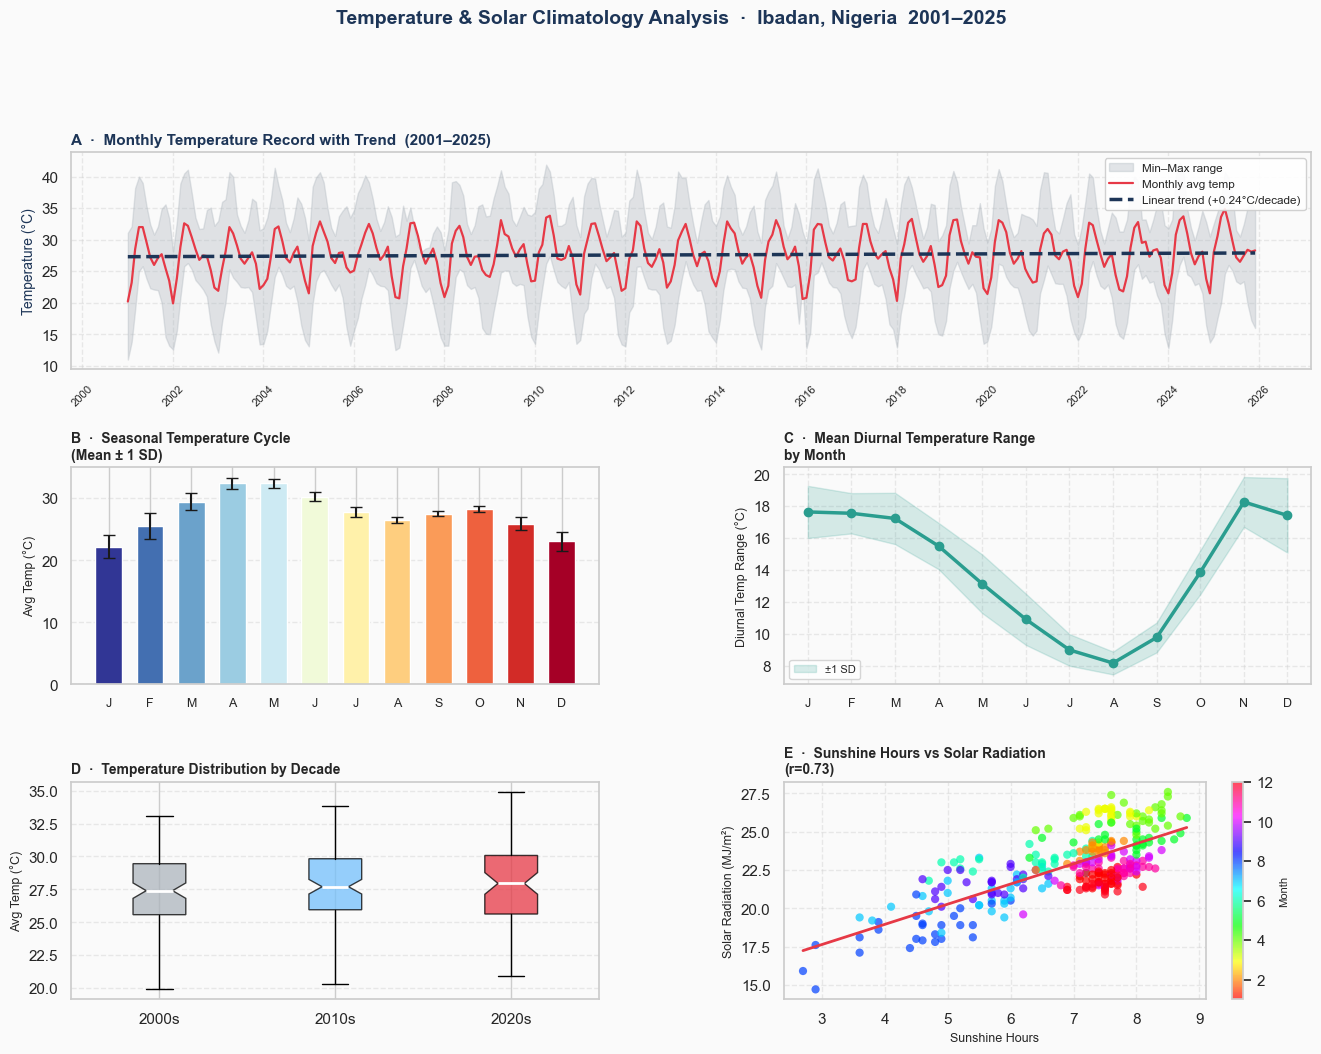

Fig 8 done


In [17]:
# ══════════════════════════════════════════════════════════════════════════
# FIGURE 8: TEMPERATURE TREND DECOMPOSITION
# ══════════════════════════════════════════════════════════════════════════
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.ndimage import gaussian_filter1d
import warnings; warnings.filterwarnings('ignore')

monthly = pd.read_csv(monthly_path)
month_order = ['Jan','Feb','Mar','April','May','June','July','Aug','Sep','Oct','Nov','Dec']
m_map = {'Apr':'April','Jun':'June','Jul':'July'}
monthly['Month'] = monthly['Month'].replace(m_map)
monthly['Month_Num'] = monthly['Month'].map({m:i+1 for i,m in enumerate(month_order)})
monthly['Date'] = pd.to_datetime(
    monthly['Year'].astype(int).astype(str) + '-' +
    monthly['Month_Num'].astype(int).astype(str).str.zfill(2) + '-01')
monthly = monthly.sort_values('Date').reset_index(drop=True)

fig = plt.figure(figsize=(16, 11), facecolor='#FAFAFA')
fig.patch.set_facecolor('#FAFAFA')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

DARK = '#1D3557'; RED = '#E63946'; BLUE = '#457B9D'; TEAL = '#2A9D8F'

# ─ Panel A: Max + Min + Avg temp time series ──────────────────────────
ax_a = fig.add_subplot(gs[0, :])
ax_a.fill_between(monthly['Date'],
                   monthly['MINIMUM TEMPERATURE (Deg C)'],
                   monthly['MAXIMUM TEMPERATURE (Deg C)'],
                   color='#ADB5BD', alpha=0.35, label='Min–Max range')
ax_a.plot(monthly['Date'], monthly['AVERAGE TEMPERATURE (Deg C)'],
          color=RED, lw=1.6, label='Monthly avg temp', zorder=4)

# trend line on avg temp
ts = monthly['AVERAGE TEMPERATURE (Deg C)'].dropna()
t_idx = np.arange(len(ts))
slope, intercept, r, p, _ = stats.linregress(t_idx, ts.values)
trend = slope * t_idx + intercept
ax_a.plot(monthly['Date'].iloc[ts.index], trend, color=DARK,
          lw=2.5, linestyle='--', label=f'Linear trend (+{slope*120:.2f}°C/decade)', zorder=5)

ax_a.set_ylabel('Temperature (°C)', fontsize=10, color=DARK)
ax_a.set_title('A  ·  Monthly Temperature Record with Trend  (2001–2025)',
               fontweight='bold', fontsize=11, color=DARK, loc='left')
import matplotlib.dates as mdates
ax_a.xaxis.set_major_locator(mdates.YearLocator(2))
ax_a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_a.tick_params(axis='x', rotation=45, labelsize=8)
ax_a.legend(fontsize=8.5, loc='upper right', framealpha=0.9)
ax_a.grid(linestyle='--', alpha=0.4)
ax_a.set_facecolor('#FAFAFA')

# ─ Panel B: Monthly climatology bar + error bars ──────────────────────
ax_b = fig.add_subplot(gs[1, 0])
clim = monthly.groupby('Month', sort=False)['AVERAGE TEMPERATURE (Deg C)'].agg(['mean','std']).reindex(month_order)
x = np.arange(12)
ax_b.bar(x, clim['mean'], yerr=clim['std'], color=[plt.cm.RdYlBu_r(v) for v in np.linspace(0,1,12)],
         capsize=4, width=0.65, error_kw={'lw':1.5})
ax_b.set_xticks(x); ax_b.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=9)
ax_b.set_ylabel('Avg Temp (°C)', fontsize=9)
ax_b.set_title('B  ·  Seasonal Temperature Cycle\n(Mean ± 1 SD)', fontweight='bold', fontsize=10, loc='left')
ax_b.grid(axis='y', linestyle='--', alpha=0.4)
ax_b.set_facecolor('#FAFAFA')

# ─ Panel C: Diurnal range (max-min) by month ─────────────────────────
ax_c = fig.add_subplot(gs[1, 1])
monthly['DTR'] = monthly['MAXIMUM TEMPERATURE (Deg C)'] - monthly['MINIMUM TEMPERATURE (Deg C)']
dtr_clim = monthly.groupby('Month', sort=False)['DTR'].agg(['mean','std']).reindex(month_order)
ax_c.plot(range(12), dtr_clim['mean'], color=TEAL, lw=2.5, marker='o', ms=6, zorder=4)
ax_c.fill_between(range(12),
                   dtr_clim['mean']-dtr_clim['std'],
                   dtr_clim['mean']+dtr_clim['std'],
                   color=TEAL, alpha=0.18, label='±1 SD')
ax_c.set_xticks(range(12))
ax_c.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=9)
ax_c.set_ylabel('Diurnal Temp Range (°C)', fontsize=9)
ax_c.set_title('C  ·  Mean Diurnal Temperature Range\nby Month', fontweight='bold', fontsize=10, loc='left')
ax_c.legend(fontsize=8); ax_c.grid(linestyle='--', alpha=0.4)
ax_c.set_facecolor('#FAFAFA')

# ─ Panel D: Decadal box plots ─────────────────────────────────────────
ax_d = fig.add_subplot(gs[2, 0])
monthly['Decade'] = (monthly['Year']//10*10).astype(int).astype(str)+'s'
decade_order = sorted(monthly['Decade'].unique())
bp_data = [monthly.loc[monthly['Decade']==d, 'AVERAGE TEMPERATURE (Deg C)'].dropna().values
           for d in decade_order]
bp = ax_d.boxplot(bp_data, labels=decade_order, patch_artist=True, notch=True,
                  medianprops=dict(color='white', lw=2))
colors_d = ['#ADB5BD','#74C0FC','#E63946','#F4A261']
for patch, color in zip(bp['boxes'], colors_d[:len(bp_data)]):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax_d.set_ylabel('Avg Temp (°C)', fontsize=9)
ax_d.set_title('D  ·  Temperature Distribution by Decade', fontweight='bold', fontsize=10, loc='left')
ax_d.grid(axis='y', linestyle='--', alpha=0.4)
ax_d.set_facecolor('#FAFAFA')

# ─ Panel E: Sunshine hours vs solar radiation scatter ─────────────────
ax_e = fig.add_subplot(gs[2, 1])
sc = monthly.dropna(subset=['SUNSHINE HOURS','SOLAR RADIATION (MJ/m2)'])
im = ax_e.scatter(sc['SUNSHINE HOURS'], sc['SOLAR RADIATION (MJ/m2)'],
                   c=sc['Month_Num'] if 'Month_Num' in sc.columns else sc['AVERAGE TEMPERATURE (Deg C)'],
                   cmap='hsv', alpha=0.7, s=35, edgecolors='none')
slope2, intercept2, r2, p2, _ = stats.linregress(sc['SUNSHINE HOURS'], sc['SOLAR RADIATION (MJ/m2)'])
xfit = np.linspace(sc['SUNSHINE HOURS'].min(), sc['SUNSHINE HOURS'].max(), 100)
ax_e.plot(xfit, slope2*xfit+intercept2, color=RED, lw=2, zorder=5)
ax_e.set_xlabel('Sunshine Hours', fontsize=9)
ax_e.set_ylabel('Solar Radiation (MJ/m²)', fontsize=9)
ax_e.set_title(f'E  ·  Sunshine Hours vs Solar Radiation\n(r={r2:.2f})',
               fontweight='bold', fontsize=10, loc='left')
plt.colorbar(im, ax=ax_e).set_label('Month', fontsize=8)
ax_e.grid(linestyle='--', alpha=0.4)
ax_e.set_facecolor('#FAFAFA')

fig.suptitle('Temperature & Solar Climatology Analysis  ·  Ibadan, Nigeria  2001–2025',
             fontsize=14, fontweight='bold', color=DARK, y=1.01)

plt.savefig('assets/fig8_temp_decomp.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
plt.close()
print("Fig 8 done")